In [2]:
import torch
from torch.distributions import Normal

import matplotlib.pyplot as plt

from typing import Callable


In [ ]:
class KleinNormal(Normal):
    r"""
    Approximate “Gaussian” on the Klein bottle, 
    obtained by (u,v) ~ Normal(loc, scale) in R^2,
    then (θ1,θ2) = (u mod 2π, v mod π). 

    Inherits most machinery from torch.distributions.Normal.
    """

In [11]:
def projection_onto_a_line(theta: torch.Tensor) -> Callable[[torch.Tensor, torch.Tensor], torch.Tensor]:
    """
    Creates a function that projects points onto a line.
    Args:
        theta: Angle tensor of any shape
    Returns:
        Function that takes x,y coordinates and projects them onto the line
    """

    def project(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return x * torch.cos(theta) + y * torch.sin(theta)

    return project


def chebyshev_2(t: torch.Tensor) -> torch.Tensor:
    """
    Chebyshev polynomial of the 2nd degree.

    Args:
        t: Input tensor of any shape

    Returns:
        Tensor of same shape as input with Chebyshev polynomial applied
    """
    return 2 * t.pow(2) - 1


def klein_filter(theta_1: torch.Tensor, theta_2: torch.Tensor) -> Callable[[torch.Tensor, torch.Tensor], torch.Tensor]:
    """
    Klein filter for given angles theta_1 and theta_2.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor

    Returns:
        Function that takes x,y coordinates and applies the Klein filter
    """
    t = projection_onto_a_line(theta_1)

    def filter_fn(x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return torch.sin(theta_2) * t(x, y) + torch.cos(theta_2) * chebyshev_2(t(x,y))

    return filter_fn


def generate_klein_filter_matrix(
    theta_1: torch.Tensor, theta_2: torch.Tensor, size: int = 3, midpoint: bool = False, device: torch.device = None
) -> torch.Tensor:
    """
    Generate a Klein filter matrix of given size for specified angles.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor
        size: Size of the matrix
        midpoint: If True, use midpoints for the grid; otherwise, use edges
        device: PyTorch device to place tensors on. If None, uses theta_1's device

    Returns:
        Tensor of shape [size, size] containing the Klein filter values
    """
    if device is None:
        device = theta_1.device

    f = klein_filter(theta_1, theta_2)

    if midpoint:
        coords = torch.linspace(-1 + 1 / size, 1 - 1 / size, size, device=device)
    else:
        coords = torch.linspace(-1, 1, size, device=device)

    X, Y = torch.meshgrid(coords, coords, indexing="ij")
    return f(X, Y)


def generate_klein_filter_matrix_via_integration(
    theta_1: torch.Tensor, theta_2: torch.Tensor, size: int = 3, num_samples: int = 100, device: torch.device = None
) -> torch.Tensor:
    """
    Generate a Klein filter matrix using Monte Carlo integration.

    Args:
        theta_1: First angle tensor
        theta_2: Second angle tensor
        size: Size of the matrix
        num_samples: Number of random samples per cell for integration
        device: PyTorch device to place tensors on. If None, uses theta_1's device

    Returns:
        Tensor of shape [size, size] containing the integrated Klein filter values
    """
    if device is None:
        device = theta_1.device

    f = klein_filter(theta_1, theta_2)
    result = torch.zeros(size, size, device=device)

    for x in range(size):
        for y in range(size):
            xmin = -1.0 + ((2 * x) / (2 * size))
            xmax = -1.0 + ((2 * (x + 1.0)) / (2 * size))
            ymin = -1.0 + ((2 * y) / (2 * size))
            ymax = -1.0 + ((2 * (y + 1.0)) / (2 * size))

            # Generate random samples in the cell
            x_samples = torch.rand(num_samples, device=device) * (xmax - xmin) + xmin
            y_samples = torch.rand(num_samples, device=device) * (ymax - ymin) + ymin

            # Compute filter values and average
            filter_values = f(x_samples, y_samples)
            result[y, x] = filter_values.mean() * (xmax - xmin) * (ymax - ymin)

    return result


In [12]:
normal_dist = Normal(torch.tensor(0.0), torch.tensor(1.0))

In [13]:
theta_1, theta_2 = normal_dist.sample(sample_shape=torch.Size([1, 2])).chunk(2, dim=-1)
theta_1, theta_2 = theta_1 % torch.pi, theta_2 % 2 * torch.pi
print(theta_1, theta_2)

tensor([[1.3166]]) tensor([[4.9714]])


In [14]:
generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=True, device=torch.device('cpu'))

tensor([[ 0.8681, -0.0797, -0.6009],
        [ 0.5809, -0.2561, -0.6666],
        [ 0.3224, -0.4037, -0.7034]])

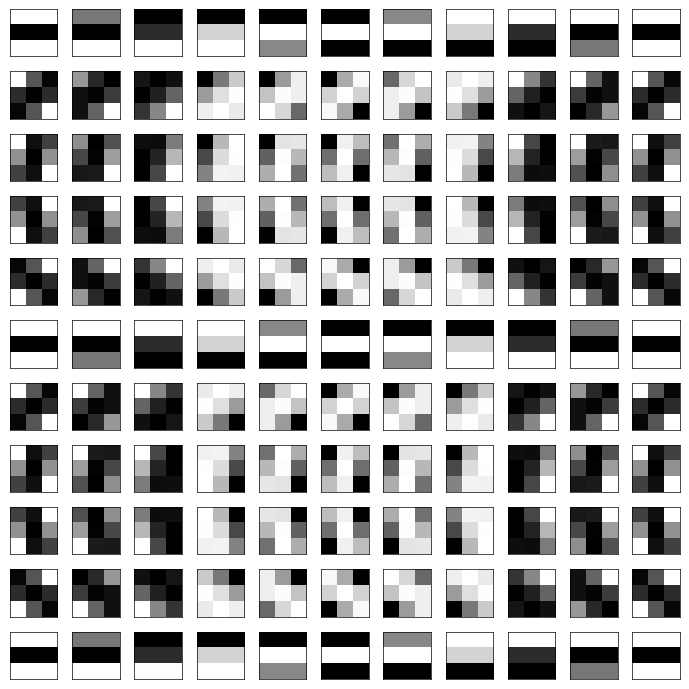

In [17]:
n = 10

fig, axes = plt.subplots(n+1, n+1, figsize=(7, 7))
for i in range(0, n+1):
    for j in range(0, n+1):
        theta_1 = torch.Tensor([2 * torch.pi * i / n])
        theta_2 = torch.Tensor([2 * torch.pi * j / n])
        filter_img = generate_klein_filter_matrix(theta_1, theta_2, size=3, midpoint=False)
        axes[i, j].imshow(filter_img.cpu().numpy(), cmap='gray', extent=[-1, 1, -1, 1])
        for spine in axes[i, j].spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.5)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])

plt.tight_layout()
plt.show()
